In [2]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import os
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts



def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
        
    return unit_concepts, raw_concepts
#how concepts removal same across algortihmimport pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os

def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts



def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
        
    return unit_concepts, raw_concepts

def get_all_cps_for_pi(folder):
    root_path = Path(folder)

    # Find all matching CSV files
    csv_pattern = 'Cluster*IOUS1024N.csv'
    csv_files = list(root_path.rglob(csv_pattern))
    
    concept_dict=defaultdict(set)
    for csv_file in csv_files:
        concepts = []
        csv_file = os.path.join(folder, csv_file)
        df = pd.read_csv(csv_file)
        for unit, formula in zip(df.unit, df.best_name):
            concept_dict[unit].update(get_indiv_concepts(formula))
    return concept_dict

def get_cluster_cps_for_pi(folder, cluster):
    csv_file = f'Cluster{cluster}IOUS1024N.csv'
    
    concept_dict=defaultdict(set)
    concepts = []
    csv_file = os.path.join(folder, csv_file)
    df = pd.read_csv(csv_file)
    for unit, formula in zip(df.unit, df.best_name):
        concept_dict[unit].update(get_indiv_concepts(formula))
    return concept_dict


REDUNDANCY

In [ ]:
import pandas as pd
from collections import defaultdict
import os
import numpy as np

models = ['BERT', 'LLAMA', 'BOWMAN']  # add your models
methods = ['lottery_ticket', 'wanda', 'CoFi']  # add your methods
cluster_range = range(1, 4)
pi = {0: '0.0', 1: '25.0', 2: '43.75', 3: '57.812', 4: '68.359', 5: '76.27'}

# Store lottery ticket idx=0 per model as fallback
lt_dense_vals = {}  # lt_dense_vals[model][cl] = value

all_dfs = {}  # all_dfs[(model, method)] = df

for model in models:
    for method in methods:
        base_path = f"/workspace/CCE_NLI/{model.upper()}/exp/{method}"
        if not os.path.exists(base_path):
            print(f"Skipping {model}/{method} — path not found")
            continue

        redundancy = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))

        for filename in sorted(os.listdir(base_path)):
            if '.ipynb' in filename or '_4cl' in filename:
                continue
            expls_path = os.path.join(base_path, filename, 'Expls')
            if not os.path.exists(expls_path):
                continue

            dense_absent = '0.0%Pruned' not in os.listdir(expls_path)

            for sparsity_idx, sparsity in enumerate(sorted(os.listdir(expls_path))):
                if '.ipynb' in sparsity: continue
                if dense_absent:
                    sparsity_idx += 1
                for cl in cluster_range:
                    expls_dict = get_cluster_cps_for_pi(os.path.join(expls_path, sparsity), cl)
                    redundancy[filename][sparsity_idx][cl] = calc_redundancy(expls_dict)

        avg = avg_keywise(redundancy)

        # Store lottery ticket dense (idx=0) as fallback
        if method == 'lottery_ticket':
            lt_dense_vals[model] = avg.get(0, {})

        # Fill in missing idx=0 from lottery ticket
        if 0 not in avg and model in lt_dense_vals:
            avg[0] = lt_dense_vals[model]

        # Build DataFrame: rows=sparsity, cols=clusters
        rows = []
        for sparsity_idx in sorted(avg.keys()):
            row = {'sparsity': pi.get(sparsity_idx, str(sparsity_idx))}
            for cl in cluster_range:
                row[f'cluster_{cl}'] = avg[sparsity_idx].get(cl, np.nan)
            rows.append(row)

        df = pd.DataFrame(rows).set_index('sparsity')
        all_dfs[(model, method)] = df
        print(f"\n=== {model} | {method} ===")
        display(df)

CONCEPT MIGRATION


LLAMA/lottery_ticket — 1 run(s): ['Run0.25_5']
0.0
25.0
Cluster1 0.5882352941176471
Cluster2 0.7894736842105263
Cluster3 0.9130434782608695
43.75
Cluster1 0.6666666666666666
Cluster2 0.8771929824561403
Cluster3 0.9456521739130435
57.813
Cluster1 0.6274509803921569
Cluster2 0.7368421052631579
Cluster3 0.9456521739130435
68.359
Cluster1 0.7450980392156863
Cluster2 0.8245614035087719
Cluster3 0.967391304347826
76.27
Cluster1 0.6078431372549019
  ✓ Run0.25_5  (6 sparsity levels)
  LLAMA/lottery_ticket — 1 run(s)
  No runs found for LLAMA/CoFi under /workspace/CCE_NLI/LLAMA/exp/CoFi

LLAMA/wanda — 1 run(s): ['Run0.25_5']
0.0
25.0
Cluster1 0.8627450980392157
Cluster2 0.9649122807017544
Cluster3 0.9021739130434783
43.75
Cluster1 0.9019607843137255
Cluster2 0.9649122807017544
Cluster3 0.8804347826086957
57.812
Cluster1 0.9019607843137255
Cluster2 0.8947368421052632
Cluster3 0.8586956521739131
68.359
Cluster1 0.8431372549019608
Cluster2 0.8421052631578947
Cluster3 0.7282608695652174
76.27
Clus

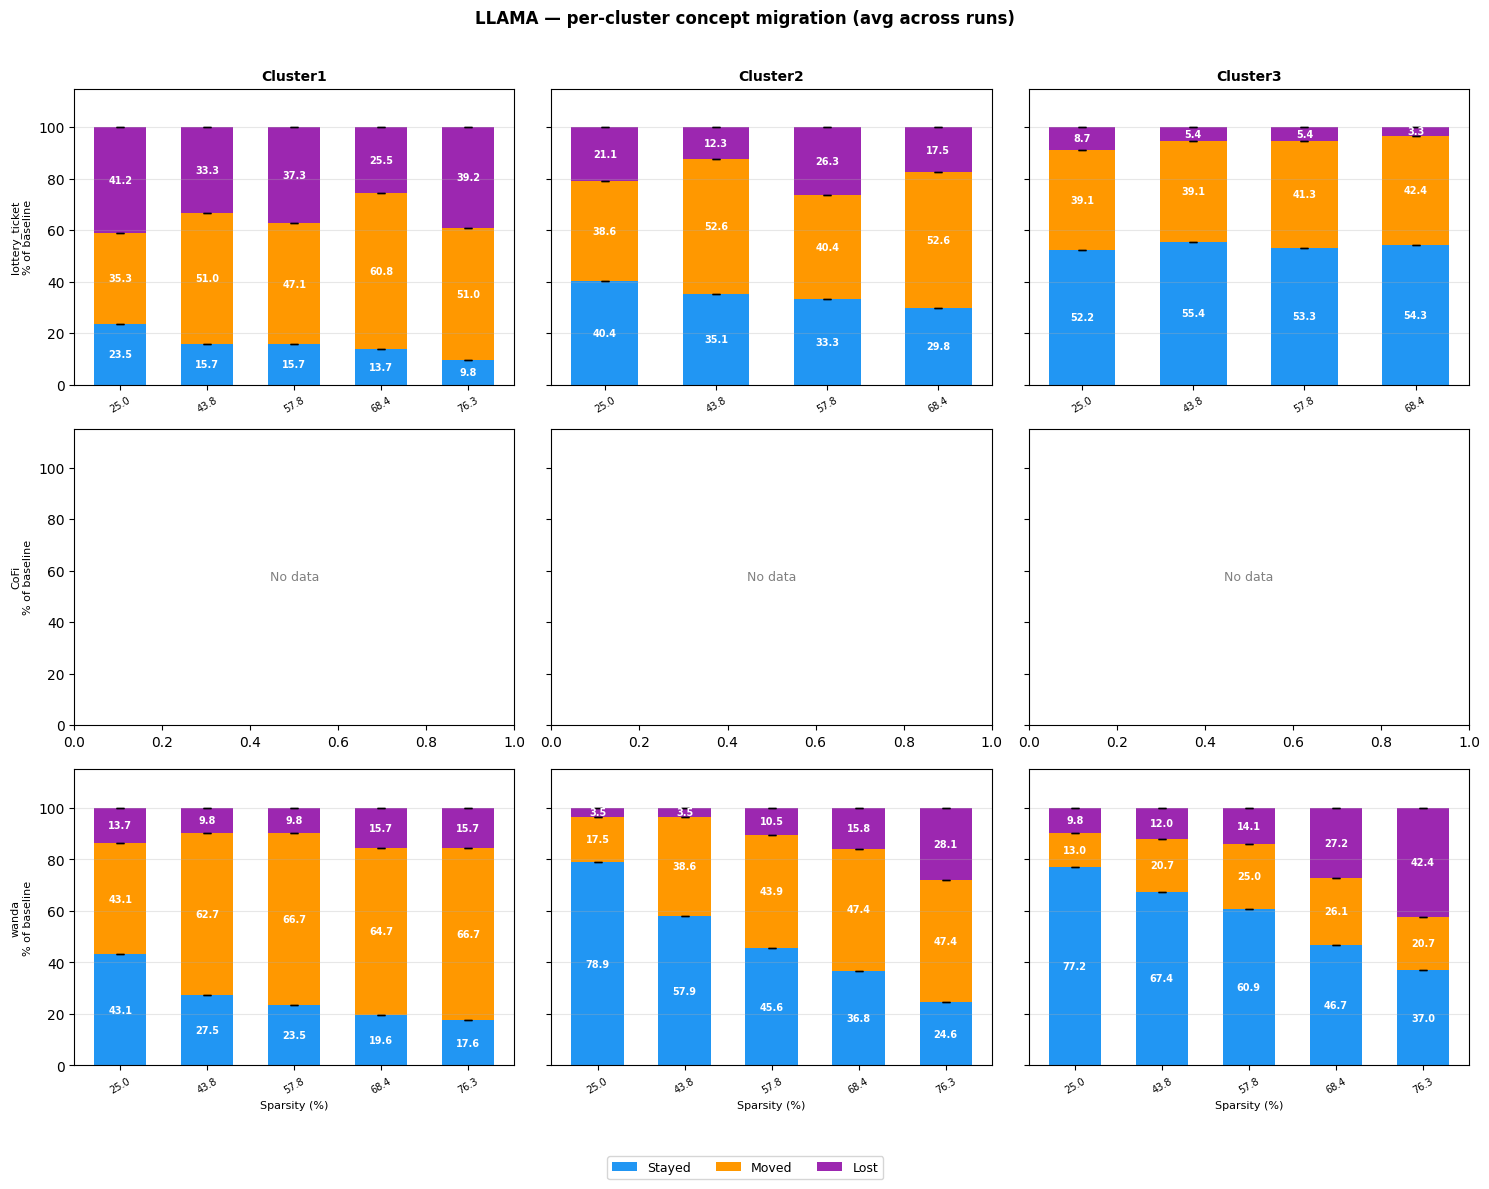

Saved all_per_cluster_BOWMAN.png


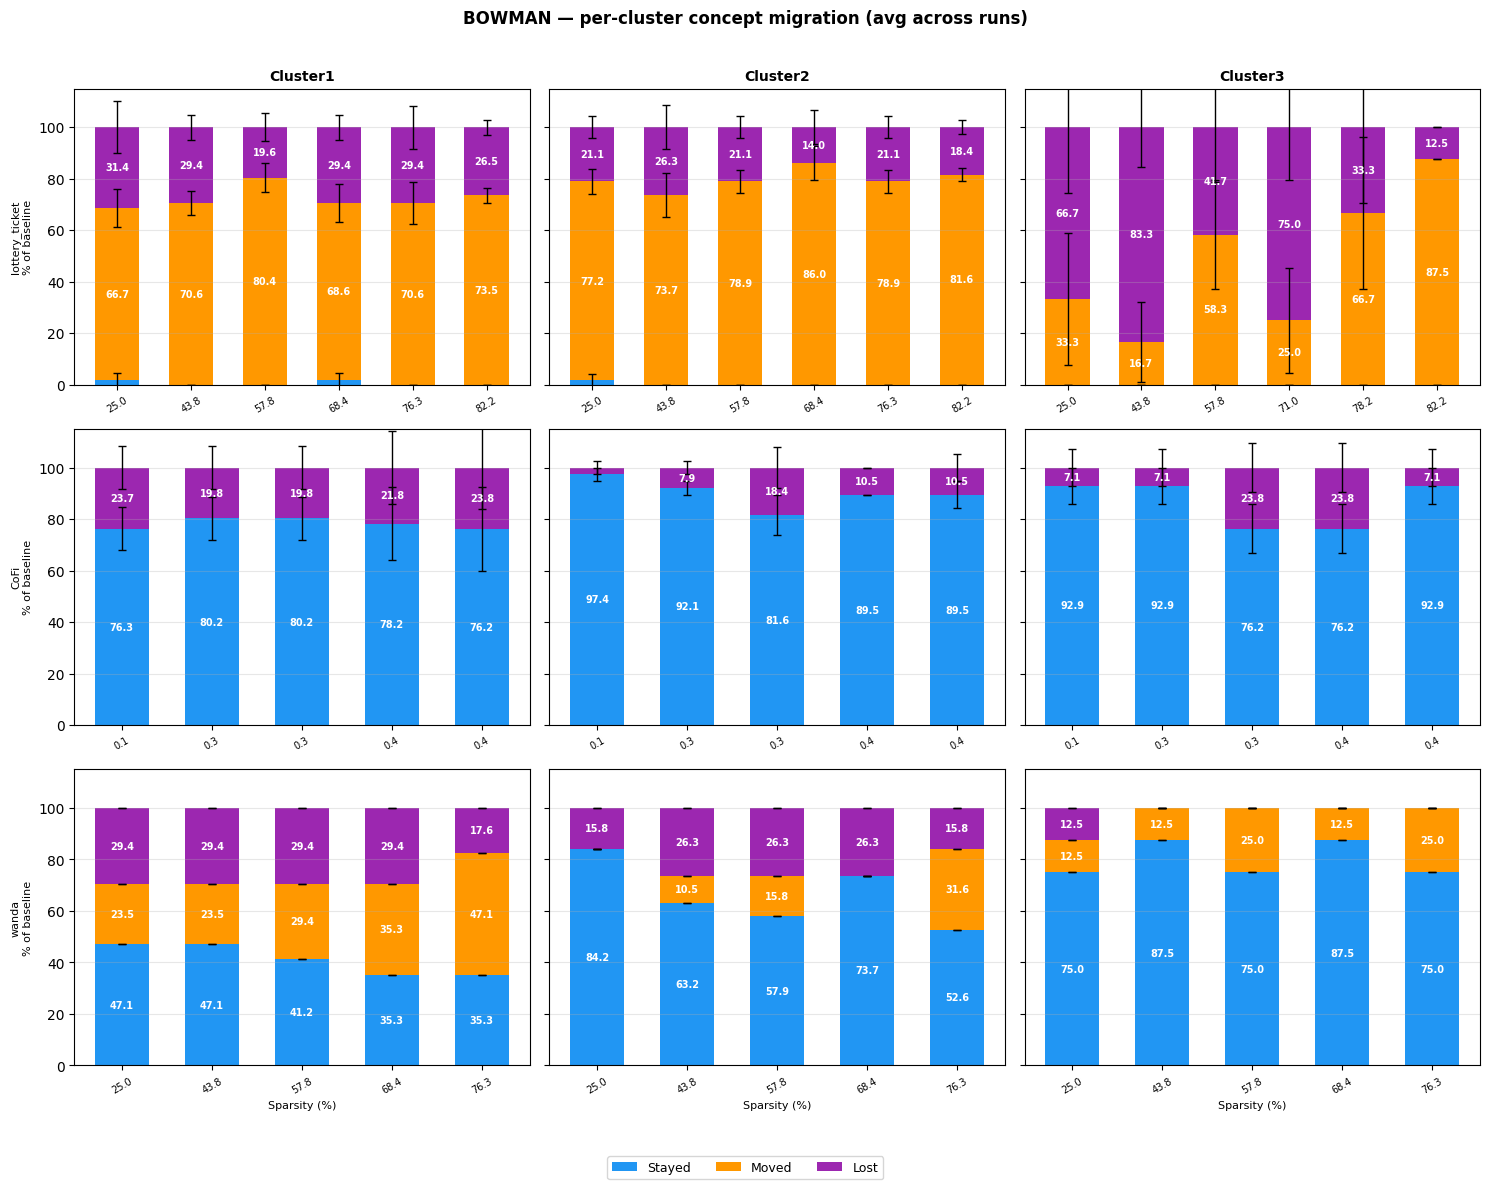

Saved all_cross_cluster.png


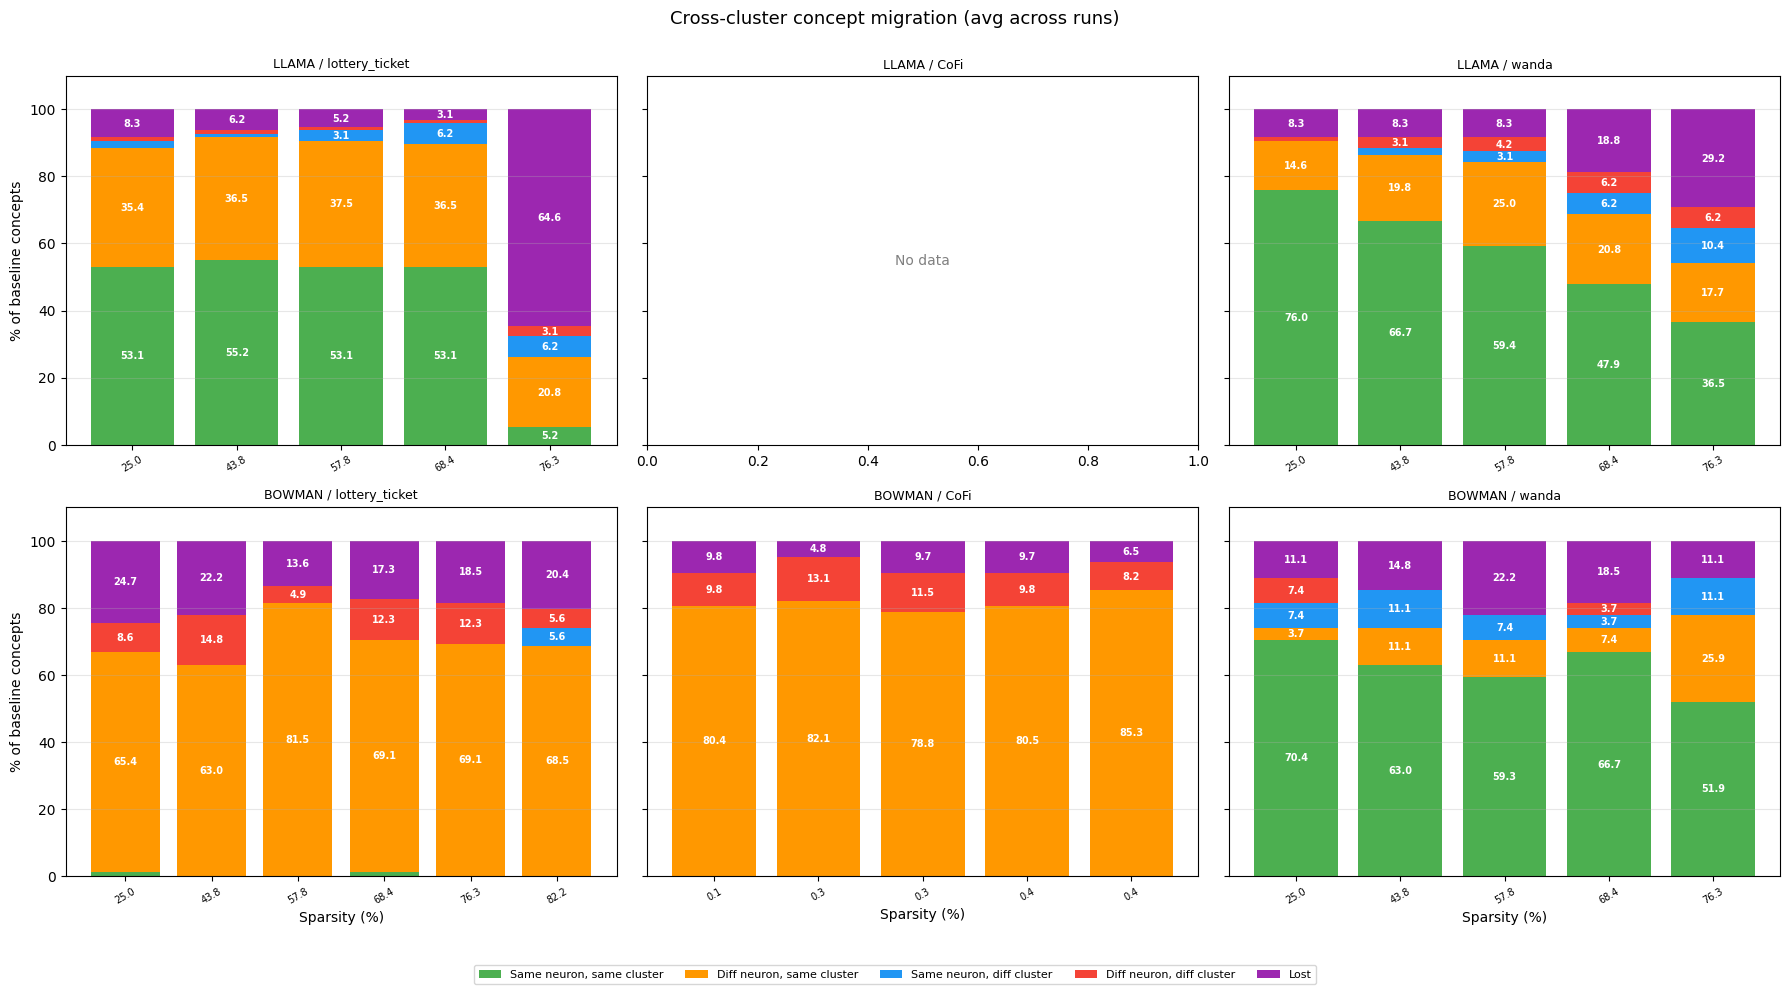

In [39]:
import pandas as pd
import re
from collections import defaultdict, Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

with open("/workspace/CCE_NLI/code/Abstractions/final_abstractions.pkl", 'rb') as f:
    abs_map = pickle.load(f)


def find_cluster(raw_concept):
    for cluster in abs_map:
        if raw_concept in abs_map[cluster]:
            return cluster


def find_abstractions(expls):
    glob = list(expls) if isinstance(expls, set) else expls
    abstracts = []
    exact_concepts_perabs = defaultdict(list)
    for concept in glob:
        raw_concept = concept.split(":")[-1]
        abstraction_cluster = find_cluster(raw_concept)
        if abstraction_cluster == 143:
            continue
        if not abstraction_cluster:
            abstraction_cluster = 150
        exact_concepts_perabs[abstraction_cluster].append(raw_concept)
        abstracts.append(abstraction_cluster)
    for a in exact_concepts_perabs:
        exact_concepts_perabs[a] = Counter(exact_concepts_perabs[a])
    return (
        Counter(abstracts),
        set(abstracts),
        dict(sorted(exact_concepts_perabs.items(),
                    key=lambda x: sum(x[1].values()), reverse=True))
    )


def load_csv_data(filepath):
    if not Path(filepath).exists():
        return None
    try:
        df = pd.read_csv(filepath)
        unit_concepts = defaultdict(set)
        for _, row in df.iterrows():
            _, concepts, _ = find_abstractions(get_indiv_concepts(row['best_name']))
            unit_concepts[row['unit']].update(concepts)
        return unit_concepts
    except Exception as e:
        print(f"  Warning: Could not load {filepath}: {e}")
        return None


def build_concept_to_units(unit_concepts_dict):
    concept_to_units = defaultdict(set)
    for unit, concepts in unit_concepts_dict.items():
        for concept in concepts:
            concept_to_units[concept].add(unit)
    return dict(concept_to_units)


# ── filesystem helpers ────────────────────────────────────────────────────────

def discover_runs(exp_root, exclude_patterns=('4cl',)):
    """Return sorted list of Run* directory names under exp_root."""
    exp_root = Path(exp_root)
    if not exp_root.exists():
        return []
    runs = []
    for d in sorted(exp_root.iterdir()):
        if not d.is_dir() or not d.name.startswith('Run'):
            continue
        if any(p in d.name for p in exclude_patterns):
            continue
        expls = d / 'Expls'
        if expls.exists() and any(
            re.match(r'[0-9.]+%Pruned', s.name)
            for s in expls.iterdir() if s.is_dir()
        ):
            runs.append(d.name)
    return runs


def get_sparsity_levels(expls_dir):
    """Return sorted list of sparsity floats found in an Expls directory."""
    sparsities = []
    for name in os.listdir(expls_dir):
        m = re.match(r'([0-9.]+)%Pruned', name)
        if m:
            sparsities.append(float(m.group(1)))
    return sorted(sparsities)


# ── single-run analysis ───────────────────────────────────────────────────────

CLUSTERS = ['Cluster1', 'Cluster2', 'Cluster3']


def _load_iteration(expls_dir, sparsity, clusters=CLUSTERS):
    """Load unit_concepts and concept_to_units for every cluster at one sparsity."""
    data = {}
    for cl in clusters:
        path = Path(expls_dir) / f"{sparsity}%Pruned" / f"{cl}IOUS1024N.csv"
        uc = load_csv_data(path)
        if uc is not None:
            data[cl] = {'unit_concepts': uc, 'concept_to_units': build_concept_to_units(uc)}
    return data


def analyze_single_run(expls_dir, clusters=CLUSTERS):
    """
    Returns
    -------
    per_cluster : dict  cluster -> list[dict]  (one dict per sparsity step, vs baseline)
    cross_cluster : list[dict]                 (one dict per sparsity step, vs baseline)
    sparsity_levels : list[float]
    """
    sparsities = get_sparsity_levels(expls_dir)
    if not sparsities:
        return None, None, []

    # baseline = sparsity 0.0
    baseline_data = _load_iteration(expls_dir, sparsities[0], clusters)
    if not baseline_data:
        return None, None, sparsities

    # global baseline
    baseline_global_c2u = defaultdict(lambda: defaultdict(set))
    for cl, d in baseline_data.items():
        for concept, units in d['concept_to_units'].items():
            baseline_global_c2u[concept][cl].update(units)
    all_baseline_concepts = set(baseline_global_c2u.keys())

    per_cluster_results  = {cl: [] for cl in clusters}
    cross_cluster_results = []

    for sparsity in sparsities:   # includes 0.0 → produces a row for each level
        print(sparsity)
        if sparsity == 0.0: continue
        curr_data = _load_iteration(expls_dir, sparsity, clusters)
        if not curr_data:
            continue

        # ── per-cluster ──────────────────────────────────────────────────────
        for cl in clusters:
            if cl not in curr_data or cl not in baseline_data:
                continue
            b_c2u  = baseline_data[cl]['concept_to_units']
            c_c2u  = curr_data[cl]['concept_to_units']
            b_cps  = set(b_c2u.keys())
            c_cps  = set(c_c2u.keys())
            common = b_cps & c_cps
            print(cl, len(common)/len(b_cps))

            stayed, moved = set(), set()
            for concept in common:
                if b_c2u[concept] & c_c2u[concept]:
                    stayed.add(concept)
                else:
                    moved.add(concept)

            total_b = len(b_cps)
            per_cluster_results[cl].append({
                'sparsity':             sparsity,
                'total_baseline':       total_b,
                'total_curr':           len(c_cps),
                'stayed_same':          len(stayed),
                'moved_to_new_unit':    len(moved),
                'disappeared':          len(b_cps - c_cps),
                'new_concepts':         len(c_cps - b_cps),
                'pct_stayed':           100 * len(stayed)  / total_b if total_b else 0,
                'pct_moved':            100 * len(moved)   / total_b if total_b else 0,
                'pct_disappeared':      100 * len(b_cps - c_cps) / total_b if total_b else 0,
            })

        # ── cross-cluster ────────────────────────────────────────────────────
        curr_global_c2u = defaultdict(lambda: defaultdict(set))
        for cl, d in curr_data.items():
            for concept, units in d['concept_to_units'].items():
                curr_global_c2u[concept][cl].update(units)
        all_curr_concepts = set(curr_global_c2u.keys())
        common_global     = all_baseline_concepts & all_curr_concepts

        same_n_same_c = same_n_diff_c = diff_n_same_c = diff_n_diff_c = 0

        for concept in common_global:
            b_cls = baseline_global_c2u[concept]
            c_cls = curr_global_c2u[concept]

            # same neuron, same cluster?
            if any(cl in c_cls and b_cls[cl] & c_cls[cl] for cl in b_cls):
                same_n_same_c += 1
                continue

            # same neuron, different cluster?
            cross = False
            for orig_cl, b_units in b_cls.items():
                for curr_cl, c_units in c_cls.items():
                    if curr_cl != orig_cl and b_units & c_units:
                        cross = True
                        break
                if cross:
                    break
            if cross:
                same_n_diff_c += 1
                continue

            # diff neuron, same cluster?
            if any(cl in c_cls for cl in b_cls):
                diff_n_same_c += 1
            else:
                diff_n_diff_c += 1

        total_b = len(all_baseline_concepts)
        disappeared = len(all_baseline_concepts - all_curr_concepts)
        cross_cluster_results.append({
            'sparsity':                    sparsity,
            'total_baseline':              total_b,
            'total_curr':                  len(all_curr_concepts),
            'same_neuron_same_cluster':    same_n_same_c,
            'same_neuron_diff_cluster':    same_n_diff_c,
            'diff_neuron_same_cluster':    diff_n_same_c,
            'diff_neuron_diff_cluster':    diff_n_diff_c,
            'disappeared':                 disappeared,
            'new_concepts':                len(all_curr_concepts - all_baseline_concepts),
            'pct_same_n_same_c':           100 * same_n_same_c / total_b if total_b else 0,
            'pct_same_n_diff_c':           100 * same_n_diff_c / total_b if total_b else 0,
            'pct_diff_n_same_c':           100 * diff_n_same_c / total_b if total_b else 0,
            'pct_diff_n_diff_c':           100 * diff_n_diff_c / total_b if total_b else 0,
            'pct_disappeared':             100 * disappeared   / total_b if total_b else 0,
        })

    return per_cluster_results, cross_cluster_results, sparsities


# ── averaging across runs ─────────────────────────────────────────────────────

def _avg_list_of_dicts(list_of_lists):
    """
    list_of_lists : list[run] of list[sparsity_step] of metric-dicts
    Returns        : list[sparsity_step] of dicts with mean and std for every numeric key.
    """
    if not list_of_lists:
        return []
    n_steps = max(len(r) for r in list_of_lists)
    averaged = []
    for si in range(n_steps):
        rows = [r[si] for r in list_of_lists if si < len(r)]
        avg_row = {}
        for key in rows[0]:
            vals = [row[key] for row in rows if isinstance(row[key], (int, float))]
            if vals:
                avg_row[key]            = float(np.mean(vals))
                avg_row[f'{key}_std']   = float(np.std(vals))
            else:
                avg_row[key] = rows[0][key]
        averaged.append(avg_row)
    return averaged


def analyze_model_method(model, method, base_path_template,
                          exclude_runs=(), clusters=CLUSTERS):
    """
    Discover all Run* dirs for (model, method), run single-run analysis on each,
    then average across runs.

    Returns
    -------
    avg_per_cluster   : dict  cluster -> list[avg_dict]
    avg_cross_cluster : list[avg_dict]
    n_runs            : int
    """
    exp_root = Path(base_path_template.format(
        model=model.upper(), method=method, run=''
    )).parent

    runs = discover_runs(exp_root)
    runs = [r for r in runs if r not in exclude_runs]
    if not runs:
        print(f"  No runs found for {model}/{method} under {exp_root}")
        return None, None, 0

    print(f"\n{model}/{method} — {len(runs)} run(s): {runs}")

    # accumulators: cluster -> list[run] of list[sparsity_step]
    per_cl_acc    = {cl: [] for cl in clusters}
    cross_cl_acc  = []
    good_runs     = 0

    for run in runs:
        expls_dir = Path(base_path_template.format(
            model=model.upper(), method=method, run=run
        ))
        if not expls_dir.exists():
            print(f"  Skipping {run}: {expls_dir} not found")
            continue
        try:
            pc, cc, sps = analyze_single_run(str(expls_dir), clusters)
            if pc is None or cc is None:
                print(f"  Skipping {run}: no data")
                continue
            for cl in clusters:
                if pc.get(cl):
                    per_cl_acc[cl].append(pc[cl])
            cross_cl_acc.append(cc)
            good_runs += 1
            print(f"  ✓ {run}  ({len(sps)} sparsity levels)")
        except Exception as e:
            print(f"  ✗ {run}: {e}")

    avg_per_cluster   = {cl: _avg_list_of_dicts(per_cl_acc[cl]) for cl in clusters}
    avg_cross_cluster = _avg_list_of_dicts(cross_cl_acc)
    return avg_per_cluster, avg_cross_cluster, good_runs

def plot_all_per_cluster(all_results, models, methods, clusters=CLUSTERS, save_path=None):
    n_methods  = len(methods)
    n_clusters = len(clusters)

    colors_stayed = '#2196F3'
    colors_moved  = '#FF9800'
    colors_lost   = '#9C27B0'
    colors_pres   = '#2196F3'  # same blue for preserved in CoFi

    for model in models:
        fig, axes = plt.subplots(n_methods, n_clusters,
                                  figsize=(5 * n_clusters, 4 * n_methods),
                                  sharey=True, squeeze=False)

        for r, method in enumerate(methods):
            avg_pc = all_results.get((model, method))

            for c, cl in enumerate(clusters):
                ax = axes[r][c]

                if c == 0:
                    ax.set_ylabel(f'{method}\n% of baseline', fontsize=8)
                if r == 0:
                    ax.set_title(cl, fontsize=10, fontweight='bold')
                if r == n_methods - 1:
                    ax.set_xlabel('Sparsity (%)', fontsize=8)

                if not avg_pc or cl not in avg_pc or not avg_pc[cl]:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                            transform=ax.transAxes, fontsize=9, color='gray')
                    continue

                rows       = avg_pc[cl]
                sparsities = [r_['sparsity'] for r_ in rows]
                x          = np.arange(len(sparsities))
                stayed     = np.array([r_['pct_stayed']                   for r_ in rows])
                moved      = np.array([r_['pct_moved']                    for r_ in rows])
                lost       = np.array([r_['pct_disappeared']              for r_ in rows])
                stayed_std = np.array([r_.get('pct_stayed_std',      0)   for r_ in rows])
                moved_std  = np.array([r_.get('pct_moved_std',       0)   for r_ in rows])
                lost_std   = np.array([r_.get('pct_disappeared_std', 0)   for r_ in rows])

                if method == 'CoFi':
                    pres     = stayed + moved
                    pres_std = np.sqrt(stayed_std**2 + moved_std**2)
                    bar_data = [
                        (pres, np.zeros(len(x)), pres_std, colors_pres,   'Preserved'),
                        (lost, pres,             lost_std, colors_lost,   'Lost'),
                    ]
                else:
                    bar_data = [
                        (stayed, np.zeros(len(x)), stayed_std, colors_stayed, 'Stayed'),
                        (moved,  stayed,            moved_std,  colors_moved,  'Moved'),
                        (lost,   stayed + moved,    lost_std,   colors_lost,   'Lost'),
                    ]

                for vals, bottoms, std, color, label in bar_data:
                    bars = ax.bar(x, vals, bottom=bottoms, color=color,
                                  label=label, width=0.6)
                    ax.errorbar(x, bottoms + vals, yerr=std,
                                fmt='none', ecolor='black',
                                elinewidth=1, capsize=3, capthick=1)
                    for bar, base, v in zip(bars, bottoms, vals):
                        if v > 3:
                            ax.text(bar.get_x() + bar.get_width() / 2,
                                    base + v / 2,
                                    f'{v:.1f}',
                                    ha='center', va='center',
                                    fontsize=7, fontweight='bold', color='white')

                ax.set_xticks(x)
                ax.set_xticklabels([f'{s:.1f}' for s in sparsities],
                                    rotation=30, fontsize=7)
                ax.set_ylim(0, 115)
                ax.grid(axis='y', alpha=0.3)

        handles, labels = axes[0][0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3,
                   bbox_to_anchor=(0.5, 0.0), fontsize=9, frameon=True)
        fig.suptitle(f'{model} — per-cluster concept migration (avg across runs)',
                     fontsize=12, fontweight='bold')
        plt.tight_layout(rect=[0, 0.05, 1, 0.97])
        if save_path:
            path = save_path.replace('.png', f'_{model}.png')
            plt.savefig(path, dpi=150, bbox_inches='tight')
            print(f"Saved {path}")
        plt.show()

def plot_all_cross_cluster(all_results, models, methods, save_path=None):
    n_rows, n_cols = len(models), len(methods)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(6 * n_cols, 5 * n_rows),
                              sharey=True, squeeze=False)

    bar_specs = [
        ('pct_same_n_same_c', 'Same neuron, same cluster', '#4CAF50'),
        ('pct_diff_n_same_c', 'Diff neuron, same cluster', '#FF9800'),
        ('pct_same_n_diff_c', 'Same neuron, diff cluster', '#2196F3'),
        ('pct_diff_n_diff_c', 'Diff neuron, diff cluster', '#F44336'),
        ('pct_disappeared',   'Lost',                       '#9C27B0'),
    ]

    for r, model in enumerate(models):
        for c, method in enumerate(methods):
            ax = axes[r][c]
            avg_cc = all_results.get((model, method))

            if not avg_cc:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=10, color='gray')
                ax.set_title(f'{model} / {method}', fontsize=9)
                continue

            sparsities = [row['sparsity'] for row in avg_cc]
            x  = np.arange(len(sparsities))
            b0 = np.zeros(len(x))

            for key, label, color in bar_specs:
                vals = np.array([row.get(key, 0) for row in avg_cc])
                bars = ax.bar(x, vals, bottom=b0, label=label, color=color)
                for bar, base, v in zip(bars, b0, vals):
                    if v > 3:
                        ax.text(bar.get_x() + bar.get_width() / 2,
                                base + v / 2,
                                f'{v:.1f}',
                                ha='center', va='center',
                                fontsize=7, fontweight='bold', color='white')
                b0 += vals

            ax.set_xticks(x)
            ax.set_xticklabels([f'{s:.1f}' for s in sparsities], rotation=30, fontsize=7)
            ax.set_ylim(0, 110)
            ax.grid(axis='y', alpha=0.3)
            ax.set_title(f'{model} / {method}', fontsize=9)
            if c == 0:
                ax.set_ylabel('% of baseline concepts')
            if r == n_rows - 1:
                ax.set_xlabel('Sparsity (%)')

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='lower center',
               ncol=len(bar_specs),
               bbox_to_anchor=(0.5, 0.0),
               fontsize=8,
               frameon=True)
    fig.suptitle('Cross-cluster concept migration (avg across runs)', fontsize=13)
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])   # leave room for legend at bottom
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved {save_path}")
    plt.show()
if __name__ == "__main__":
    BASE = "/workspace/CCE_NLI/{model}/exp/{method}/{run}/Expls/"
    MODELS  = ['LLAMA', 'BOWMAN']
    METHODS = ['lottery_ticket', 'CoFi', 'wanda']
    EXCLUDE = {('LLAMA', 'lottery_ticket'): ('Run0.25_6','Run0.25_7')}

    all_per_cluster   = {}  # (model, method) -> avg_pc
    all_cross_cluster = {}  # (model, method) -> avg_cc

    for model in MODELS:
        for method in METHODS:
            exclude = EXCLUDE.get((model, method), ())
            avg_pc, avg_cc, n_runs = analyze_model_method(
                model, method, BASE, exclude_runs=exclude)
            if avg_pc is None:
                continue
            all_per_cluster[(model, method)]   = avg_pc
            all_cross_cluster[(model, method)] = avg_cc
            print(f"  {model}/{method} — {n_runs} run(s)")

    plot_all_per_cluster(all_per_cluster,   MODELS, METHODS,
                         save_path='all_per_cluster.png')
    plot_all_cross_cluster(all_cross_cluster, MODELS, METHODS,
                           save_path='all_cross_cluster.png')